Note: VEP Annotation of EG PIK3CA hits

In [2]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Load Data

In [4]:
#EG smooth hits zscores file
zscores_smooth_hits = pd.read_excel("data/plots/FindHits/EG_zscores_smooth_hits.xlsx")

#Beagle-generated file EG
EG_beagle = pd.read_csv("data/1_Beagle_design_files/EG/EG-guides.txt", sep="\t")


In [7]:
#Filter for PIK3CA
PIK3CA_hits_zscores = zscores_smooth_hits[zscores_smooth_hits["Target Gene Symbol"] == "PIK3CA"]
PIK3CA_beagle = EG_beagle[(EG_beagle["Target Gene Symbol"] == "PIK3CA") & (EG_beagle['Edit Type'] == "C-T")]

In [8]:
PIK3CA_hits_zscores.head()

,sgRNA Sequence,Target Gene Symbol,Edit Type,zscore,aa_change,condition,aa_change_pos_min,zscore_smoothed
0,TTCTCCTGCTCAGTGATTTC,PIK3CA,CBE,-7.690668,"Q546Q, E547K",HT29 + Pictilisib,546,-7.533160
1,CTCCTGCTCAGTGATTTCAG,PIK3CA,CBE,-10.477171,"E545E, Q546Q",HT29 + Pictilisib,545,-7.459769
2,CCTGCTCAGTGATTTCAGAG,PIK3CA,CBE,-8.414867,E545K,HT29 + Pictilisib,545,-7.459769
3,TGCTCAGTGATTTCAGAGAG,PIK3CA,CBE,-7.232506,E545K,HT29 + Pictilisib,545,-7.459769
4,GCTCAGTGATTTCAGAGAGA,PIK3CA,CBE,-7.650514,E545K,HT29 + Pictilisib,545,-7.459769


In [9]:
#Check if there are any guides duplicated in the zscores file
duplicated_guides_zscore=PIK3CA_hits_zscores[PIK3CA_hits_zscores.duplicated(subset=["sgRNA Sequence", "condition"], keep=False)]
duplicated_guides_zscore

,sgRNA Sequence,Target Gene Symbol,Edit Type,zscore,aa_change,condition,aa_change_pos_min,zscore_smoothed


In [10]:
PIK3CA_beagle.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
24565,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CATTGTTCTGATTCTTTGCA,GAGGCATTGTTCTGATTCTTTGCAAGTTTT,AG,179198809,antisense,179198821G>A,C_8,-5G>A,(NC),UTR,NaN,NaN
24567,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GAGGCATTGTTCTGATTCTT,CGTGGAGGCATTGTTCTGATTCTTTGCAAG,TG,179198813,antisense,179198828G>A,C_5,3G>A,Met1Ile,Missense,NaN,NaN
24569,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TGGTCGTGGAGGCATTGTTC,ATGATGGTCGTGGAGGCATTGTTCTGATTC,TG,179198821,antisense,179198836G>A,C_5,11G>A,Arg4Gln,Missense,NaN,NaN
24571,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ATGCCTCCACGACCATCATC,AACAATGCCTCCACGACCATCATCAGGTGA,AG,179198826,sense,"179198829C>T;179198830C>T, 179198832C>T;179198...","C_4;C_5, C_7;C_8","4C>T;5C>T, 7C>T;8C>T","Pro2Phe, Pro3Leu","Missense, Missense",NaN,NaN
24573,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GATGATGGTCGTGGAGGCAT,ACCTGATGATGGTCGTGGAGGCATTGTTCT,TG,179198826,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#Check if there are any guides duplicated in the beagle file
duplicated_guides_beagle=PIK3CA_beagle[PIK3CA_beagle['sgRNA Sequence'].duplicated(keep=False)]
duplicated_guides_beagle

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note


## Merge z-scores and Beagle Files

In [12]:
PIK3CA_merged = PIK3CA_beagle.merge(PIK3CA_hits_zscores, left_on='sgRNA Sequence', right_on='sgRNA Sequence', how='inner')

In [13]:
PIK3CA_merged.head()

,Input,CRISPR Enzyme,Edit Type_x,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol_x,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,Target Gene Symbol_y,Edit Type_y,zscore,aa_change,condition,aa_change_pos_min,zscore_smoothed
0,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CACCTGATGATGGTCGTGGA,AGTTCACCTGATGATGGTCGTGGAGGCATT,GG,179198831,antisense,179198847G>A,C_4,22G>A,Gly8Ser,Missense,NaN,NaN,PIK3CA,CBE,-0.002100,G8S,HT29 + Linsitinib,8,0.728357
1,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TCACCTGATGATGGTCGTGG,CAGTTCACCTGATGATGGTCGTGGAGGCAT,AG,179198832,antisense,179198847G>A;179198848G>A,C_5;C_4,22G>A;23G>A,Gly8Asn,Missense,NaN,NaN,PIK3CA,CBE,0.048732,G8N,HT29 + Linsitinib,8,0.728357
2,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GTTCACCTGATGATGGTCGT,CACAGTTCACCTGATGATGGTCGTGGAGGC,GG,179198834,antisense,"179198847G>A;179198848G>A, 179198850G>A","C_7;C_6, C_4","22G>A;23G>A, 25G>A","Gly8Asn, Glu9Lys","Missense, Missense",NaN,NaN,PIK3CA,CBE,1.932214,"G8N, E9K",HT29 + Linsitinib,8,0.728357
3,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,AGTTCACCTGATGATGGTCG,CCACAGTTCACCTGATGATGGTCGTGGAGG,TG,179198835,antisense,"179198847G>A;179198848G>A, 179198850G>A","C_8;C_7, C_5","22G>A;23G>A, 25G>A","Gly8Asn, Glu9Lys","Missense, Missense",NaN,NaN,PIK3CA,CBE,1.127493,"G8N, E9K",HT29 + Linsitinib,8,0.728357
4,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ACAGTTCACCTGATGATGGT,CCCCACAGTTCACCTGATGATGGTCGTGGA,CG,179198837,antisense,179198850G>A,C_7,25G>A,Glu9Lys,Missense,NaN,NaN,PIK3CA,CBE,1.743905,E9K,HT29 + Linsitinib,9,0.924065


## HGVS Identifier

In [14]:
PIK3CA_merged = PIK3CA_merged.copy()
PIK3CA_merged["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in PIK3CA_merged.iterrows()
]

In [36]:
#Flatten the list of HGVS notations
variants_hgvs = [v for vs in PIK3CA_merged["hgvs"] if vs != "-" for v in vs]

In [38]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/EG/EG-PIK3CA-SmoothHits-HGVS.txt", "w") as f:
    for variant in variants_hgvs:
        f.write(f"{variant}\n")

## Analysis of VEP Results

In [15]:
#Load VEP results
#'-' is a placeholder for missing values in the VEP file 
PIK3CA_vep = pd.read_csv("data/6_VEP/EG/EG-PIK3CA-SmoothHits-VEP.txt", sep="\t", na_values="-")

In [ ]:
VEP_info = pd.DataFrame({
    'dtype': PIK3CA_vep.dtypes,
    'non-null count': PIK3CA_vep.notna().sum(),
    'missing (%)': PIK3CA_vep.isna().mean() * 100,
    'n_unique': PIK3CA_vep.nunique(),
    'example': PIK3CA_vep.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(PIK3CA_vep)} rows and {len(PIK3CA_vep.columns)} columns')
VEP_info

In [16]:
duplicated_rows= PIK3CA_vep[PIK3CA_vep.duplicated(keep=False)]

In [17]:
duplicated_rows.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT,PolyPhen,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
0,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,deleterious(0.02),probably_damaging(0.966),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,G,26.5,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,deleterious(0.02),probably_damaging(0.966),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,G,26.5,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,deleterious(0.02),probably_damaging(0.966),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,G,26.5,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.

In [18]:
len(PIK3CA_vep)

226

In [19]:
len(duplicated_rows)

202

## Post Processing of VEP Output

### Drop Duplicates
Since different guides can make the same edit, there are repeated HGVS identifiers for which the Ensembl output is the same. Further on, drop these duplicates when creating the HGVS identifier file.

In [20]:
PIK3CA_vep = PIK3CA_vep.drop_duplicates(subset=["#Uploaded_variation"], ignore_index=True)

In [21]:
PIK3CA_vep.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT,PolyPhen,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
0,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,deleterious(0.02),probably_damaging(0.966),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.00,0.0,PIK3CA,NaN,NaN,0.221,G,26.50,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENST00000263967.4:c.23G>A,3:179198848-179198848,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.23G>A,ENSP00000263967.3:p.Gly8Asp,346.0,23.0,8.0,G/D,gGt/gAt,"rs2108385018,COSV55910104",G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,deleterious(0.04),probably_damaging(0.985),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0,1","0,1",NaN,COSMIC::COSM3205590,NaN,NaN,NaN,NaN,NaN,0.981558,NaN,NaN,0.522,NaN,NaN,NaN,likely_pathogenic,0.9772,-32.0,0.0,6.0,-1.0,0.0,0.0,0.00,0.0,PIK3CA,NaN,NaN,0.221,G,26.40,4.714809,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENST00000263967.4:c.25G>A,3:179198850-179198850,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.25G>A,ENSP00000263967.3:p.Glu9Lys,348.0,25.0,9.0,E/K,Gaa/Aaa,COSV108030227,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,deleterious(0),possibly_damaging(0.842),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,COSMIC::COSM10563854,NaN,NaN,NaN,NaN,NaN,0.989899,NaN,NaN,0.547,NaN,NaN,NaN,likely_pathogenic,0.9882,-3.0,-34.0,-3.0,38.0,0.0,0.0,0.36,0.0,PIK3CA,NaN,NaN,0.221,G,33.00,5.789559,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENST00000263967.4:c.28C>T,3:179198853-179198853,T,synonymous_variant,LOW,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.28C>T,ENSP00000263967.3:p.Leu10%3D,351.0,28.0,10.0,L,Ctg/Ttg,rs2108385041,C,C/T,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM

### Separate SIFT and PolyPhen into class and score

In [22]:
# Split SIFT column
PIK3CA_vep["SIFT_class"] = PIK3CA_vep["SIFT"].str.extract(r"^([a-zA-Z_]+)")
PIK3CA_vep["SIFT_pathogenicity"] = PIK3CA_vep["SIFT"].str.extract(r"\(([\d.]+)\)").astype(float)

#Split PolyPhen column
PIK3CA_vep["PolyPhen_class"] = PIK3CA_vep["PolyPhen"].str.extract(r"^([a-zA-Z_]+)")
PIK3CA_vep["PolyPhen_pathogenicity"] = PIK3CA_vep["PolyPhen"].str.extract(r"\(([\d.]+)\)").astype(float)

In [23]:
# Insert new columns at the same positions
PIK3CA_vep.insert(PIK3CA_vep.columns.get_loc("SIFT"), "SIFT_class", PIK3CA_vep.pop("SIFT_class"))
PIK3CA_vep.insert(PIK3CA_vep.columns.get_loc("SIFT_class"), "SIFT_pathogenicity", PIK3CA_vep.pop("SIFT_pathogenicity"))

PIK3CA_vep.insert(PIK3CA_vep.columns.get_loc("PolyPhen"), "PolyPhen_class", PIK3CA_vep.pop("PolyPhen_class"))
PIK3CA_vep.insert(PIK3CA_vep.columns.get_loc("PolyPhen_class"), "PolyPhen_pathogenicity", PIK3CA_vep.pop("PolyPhen_pathogenicity"))


In [24]:
# Drop original columns
PIK3CA_vep.drop(columns=["SIFT", "PolyPhen"], inplace=True)

In [25]:
PIK3CA_vep.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
0,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.02,deleterious,0.966,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.00,0.0,PIK3CA,NaN,NaN,0.221,G,26.50,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENST00000263967.4:c.23G>A,3:179198848-179198848,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.23G>A,ENSP00000263967.3:p.Gly8Asp,346.0,23.0,8.0,G/D,gGt/gAt,"rs2108385018,COSV55910104",G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.04,deleterious,0.985,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0,1","0,1",NaN,COSMIC::COSM3205590,NaN,NaN,NaN,NaN,NaN,0.981558,NaN,NaN,0.522,NaN,NaN,NaN,likely_pathogenic,0.9772,-32.0,0.0,6.0,-1.0,0.0,0.0,0.00,0.0,PIK3CA,NaN,NaN,0.221,G,26.40,4.714809,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENST00000263967.4:c.25G>A,3:179198850-179198850,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.25G>A,ENSP00000263967.3:p.Glu9Lys,348.0,25.0,9.0,E/K,Gaa/Aaa,COSV108030227,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.00,deleterious,0.842,possibly_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,COSMIC::COSM10563854,NaN,NaN,NaN,NaN,NaN,0.989899,NaN,NaN,0.547,NaN,NaN,NaN,likely_pathogenic,0.9882,-3.0,-34.0,-3.0,38.0,0.0,0.0,0.36,0.0,PIK3CA,NaN,NaN,0.221,G,33.00,5.789559,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENST00000263967.4:c.28C>T,3:179198853-179198853,T,synonymous_variant,LOW,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.28C>T,ENSP00000263967.3:p.Leu10%3D,351.0,28.0,10.0,L,Ctg/Ttg,rs210838504

### Convert the amino acid change to InitialAA+Position+FinalAA

In [26]:
# Create a new column with the AA change 
PIK3CA_vep["aa_change"] = (
    PIK3CA_vep["Amino_acids"].str[0] + 
    PIK3CA_vep["Protein_position"].astype(int).astype(str) + 
    PIK3CA_vep["Amino_acids"].str[-1]
)

In [27]:
#Change the position for readability
PIK3CA_vep.insert(PIK3CA_vep.columns.get_loc("Codons"), "aa_change", PIK3CA_vep.pop("aa_change"))

## Merge z-scores with VEP annotations

In [28]:
PIK3CA_vep.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,aa_change,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
0,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,G8S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.02,deleterious,0.966,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.00,0.0,PIK3CA,NaN,NaN,0.221,G,26.50,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENST00000263967.4:c.23G>A,3:179198848-179198848,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.23G>A,ENSP00000263967.3:p.Gly8Asp,346.0,23.0,8.0,G/D,G8D,gGt/gAt,"rs2108385018,COSV55910104",G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.04,deleterious,0.985,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0,1","0,1",NaN,COSMIC::COSM3205590,NaN,NaN,NaN,NaN,NaN,0.981558,NaN,NaN,0.522,NaN,NaN,NaN,likely_pathogenic,0.9772,-32.0,0.0,6.0,-1.0,0.0,0.0,0.00,0.0,PIK3CA,NaN,NaN,0.221,G,26.40,4.714809,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENST00000263967.4:c.25G>A,3:179198850-179198850,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.25G>A,ENSP00000263967.3:p.Glu9Lys,348.0,25.0,9.0,E/K,E9K,Gaa/Aaa,COSV108030227,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.00,deleterious,0.842,possibly_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,COSMIC::COSM10563854,NaN,NaN,NaN,NaN,NaN,0.989899,NaN,NaN,0.547,NaN,NaN,NaN,likely_pathogenic,0.9882,-3.0,-34.0,-3.0,38.0,0.0,0.0,0.36,0.0,PIK3CA,NaN,NaN,0.221,G,33.00,5.789559,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENST00000263967.4:c.28C>T,3:179198853-179198853,T,synonymous_variant,LOW,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.28C>T,ENSP00000263967.3:p.Leu10%3D,351.0,28.0,10.0

In [29]:
#check the duplicates in the aa_change column
duplicated_aa_change = PIK3CA_vep[PIK3CA_vep.duplicated(subset=["aa_change"], keep=False)]
sorted_duplicated_aa_change = duplicated_aa_change.sort_values(by=["aa_change"])
sorted_duplicated_aa_change

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,aa_change,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
3,ENST00000263967.4:c.28C>T,3:179198853-179198853,T,synonymous_variant,LOW,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.28C>T,ENSP00000263967.3:p.Leu10%3D,351.0,28.0,10.0,L,L10L,Ctg/Ttg,rs2108385041,C,C/T,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.0,-5.0,-6.0,35.0,0.0,0.0,0.11,0.0,PIK3CA,NaN,NaN,0.221,C,12.23,1.205281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENST00000263967.4:c.30G>A,3:179198855-179198855,A,synonymous_variant,LOW,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.30G>A,ENSP00000263967.3:p.Leu10%3D,353.0,30.0,10.0,L,L10L,ctG/ctA,rs758862912,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,0.000017,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,likely_benign,NaN,1,NaN,"ClinVar::RCV003298838,RCV001478167,VCV001140920",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.0,-39.0,-8.0,-1.0,0.0,0.0,0.03,0.0,PIK3CA,NaN,NaN,0.221,G,11.95,1.168265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ENST00000263967.4:c.32G>A,3:179198857-179198857,A,stop_gained,HIGH,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.32G>A,ENSP00000263967.3:p.Trp11Ter,355.0,32.0,11.0,W/*,W11*,tGg/tAg,"rs2108385056,COSV55873743,COSV55891755",G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0,1,1","0,1,1",NaN,COSMIC::COSM582520--COSMIC::COSM3974285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,-9.0,-10.0,31.0,0.0,0.0,0.01,0.0,PIK3CA,NaN,NaN,0.221,G,37.00,8.038050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ENST00000263967.4:c.33G>A,3:179198858-179198858,A,stop_gained,HIGH,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.33G>A,ENSP00000263967.3:p.Trp11Ter,356.0,33.0,11.0,W/*,W11*,tgG/tgA,COSV104566693,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MAN

In [26]:
PIK3CA_merged.head()

,Input,CRISPR Enzyme,Edit Type_x,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol_x,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,Target Gene Symbol_y,Edit Type_y,zscore,aa_change,condition,aa_change_pos_min,zscore_smoothed,hgvs
0,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CACCTGATGATGGTCGTGGA,AGTTCACCTGATGATGGTCGTGGAGGCATT,GG,179198831,antisense,179198847G>A,C_4,22G>A,Gly8Ser,Missense,NaN,NaN,PIK3CA,CBE,-0.002100,G8S,HT29 + Linsitinib,8,0.728357,[ENST00000263967.4:c.22G>A]
1,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TCACCTGATGATGGTCGTGG,CAGTTCACCTGATGATGGTCGTGGAGGCAT,AG,179198832,antisense,179198847G>A;179198848G>A,C_5;C_4,22G>A;23G>A,Gly8Asn,Missense,NaN,NaN,PIK3CA,CBE,0.048732,G8N,HT29 + Linsitinib,8,0.728357,"[ENST00000263967.4:c.22G>A, ENST00000263967.4:..."
2,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GTTCACCTGATGATGGTCGT,CACAGTTCACCTGATGATGGTCGTGGAGGC,GG,179198834,antisense,"179198847G>A;179198848G>A, 179198850G>A","C_7;C_6, C_4","22G>A;23G>A, 25G>A","Gly8Asn, Glu9Lys","Missense, Missense",NaN,NaN,PIK3CA,CBE,1.932214,"G8N, E9K",HT29 + Linsitinib,8,0.728357,"[ENST00000263967.4:c.22G>A, ENST00000263967.4:..."
3,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,AGTTCACCTGATGATGGTCG,CCACAGTTCACCTGATGATGGTCGTGGAGG,TG,179198835,antisense,"179198847G>A;179198848G>A, 179198850G>A","C_8;C_7, C_5","22G>A;23G>A, 25G>A","Gly8Asn, Glu9Lys","Missense, Missense",NaN,NaN,PIK3CA,CBE,1.127493,"G8N, E9K",HT29 + Linsitinib,8,0.728357,"[ENST00000263967.4:c.22G>A, ENST00000263967.4:..."
4,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ACAGTTCACCTGATGATGGT,CCCCACAGTTCACCTGATGATGGTCGTGGA,CG,179198837,antisense,179198850G>A,C_7,25G>A,Glu9Lys,Missense,NaN,NaN,PIK3CA,CBE,1.743905,E9K,HT29 + Linsitinib,9,0.924065,[ENST00000263967.4:c.25G>A]


### Explode the HGVS column

In [30]:
PIK3CA_merged_exploded = PIK3CA_merged.explode("hgvs")
PIK3CA_merged_exploded["hgvs"] = PIK3CA_merged_exploded["hgvs"].str.strip()

In [31]:
PIK3CA_merged_exploded.head()

,Input,CRISPR Enzyme,Edit Type_x,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol_x,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,Target Gene Symbol_y,Edit Type_y,zscore,aa_change,condition,aa_change_pos_min,zscore_smoothed,hgvs
0,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CACCTGATGATGGTCGTGGA,AGTTCACCTGATGATGGTCGTGGAGGCATT,GG,179198831,antisense,179198847G>A,C_4,22G>A,Gly8Ser,Missense,NaN,NaN,PIK3CA,CBE,-0.002100,G8S,HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.22G>A
1,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TCACCTGATGATGGTCGTGG,CAGTTCACCTGATGATGGTCGTGGAGGCAT,AG,179198832,antisense,179198847G>A;179198848G>A,C_5;C_4,22G>A;23G>A,Gly8Asn,Missense,NaN,NaN,PIK3CA,CBE,0.048732,G8N,HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.22G>A
1,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TCACCTGATGATGGTCGTGG,CAGTTCACCTGATGATGGTCGTGGAGGCAT,AG,179198832,antisense,179198847G>A;179198848G>A,C_5;C_4,22G>A;23G>A,Gly8Asn,Missense,NaN,NaN,PIK3CA,CBE,0.048732,G8N,HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.23G>A
2,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GTTCACCTGATGATGGTCGT,CACAGTTCACCTGATGATGGTCGTGGAGGC,GG,179198834,antisense,"179198847G>A;179198848G>A, 179198850G>A","C_7;C_6, C_4","22G>A;23G>A, 25G>A","Gly8Asn, Glu9Lys","Missense, Missense",NaN,NaN,PIK3CA,CBE,1.932214,"G8N, E9K",HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.22G>A
2,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GTTCACCTGATGATGGTCGT,CACAGTTCACCTGATGATGGTCGTGGAGGC,GG,179198834,antisense,"179198847G>A;179198848G>A, 179198850G>A","C_7;C_6, C_4","22G>A;23G>A, 25G>A","Gly8Asn, Glu9Lys","Missense, Missense",NaN,NaN,PIK3CA,CBE,1.932214,"G8N, E9K",HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.23G>A


### Merge with VEP on HGVS

In [32]:
columns_to_keep_zscores = ['sgRNA Sequence', 
                           'Target Transcript ID',
                           'Target Gene Symbol_y',
                           'Edit Type_y',
                           'Nucleotide Edits',
                           'Amino Acid Edits',
                           'Mutation Category',
                           'zscore',
                           'aa_change',
                           'condition',
                           'aa_change_pos_min',
                           'zscore_smoothed',
                           'hgvs']
PIK3CA_merged_vep = pd.merge( PIK3CA_merged_exploded[columns_to_keep_zscores],
    PIK3CA_vep,
    how="left",
    left_on="hgvs",
    right_on="#Uploaded_variation" 
)

In [33]:
PIK3CA_merged_vep.head()

,sgRNA Sequence,Target Transcript ID,Target Gene Symbol_y,Edit Type_y,Nucleotide Edits,Amino Acid Edits,Mutation Category,zscore,aa_change_x,condition,aa_change_pos_min,zscore_smoothed,hgvs,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,aa_change_y,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
0,CACCTGATGATGGTCGTGGA,ENST00000263967.4,PIK3CA,CBE,22G>A,Gly8Ser,Missense,-0.002100,G8S,HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.22G>A,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,G8S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.02,deleterious,0.966,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,G,26.5,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCACCTGATGATGGTCGTGG,ENST00000263967.4,PIK3CA,CBE,22G>A;23G>A,Gly8Asn,Missense,0.048732,G8N,HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.22G>A,ENST00000263967.4:c.22G>A,3:179198847-179198847,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.22G>A,ENSP00000263967.3:p.Gly8Ser,345.0,22.0,8.0,G/S,G8S,Ggt/Agt,rs2108385009,G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.02,deleterious,0.966,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977721,NaN,NaN,0.430,NaN,NaN,NaN,likely_pathogenic,0.8823,-31.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,G,26.5,4.731905,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCACCTGATGATGGTCGTGG,ENST00000263967.4,PIK3CA,CBE,22G>A;23G>A,Gly8Asn,Missense,0.048732,G8N,HT29 + Linsitinib,8,0.728357,ENST00000263967.4:c.23G>A,ENST00000263967.4:c.23G>A,3:179198848-179198848,A,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,2/21,NaN,ENST00000263967.4:c.23G>A,ENSP00000263967.3:p.Gly8Asp,346.0,23.0,8.0,G/D,G8D,gGt/gAt,"rs2108385018,COSV55910104",G,G/A,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.04,deleteriou

### Filter for the minimal protein position

In [34]:
PIK3CA_merged_vep_min_pos['condition'].value_counts()

NameError: name 'PIK3CA_merged_vep_min_pos' is not defined

In [105]:
PIK3CA_merged_vep['condition'].value_counts()

condition
HT29 + Linsitinib    95
HT29 + Pictilisib    67
HT29 + SCH772984     31
A375 + Linsitinib    18
A375 + SCH772984      8
Name: count, dtype: int64

In [103]:
PIK3CA_merged['condition'].value_counts()

condition
HT29 + Linsitinib    57
HT29 + Pictilisib    39
HT29 + SCH772984     17
A375 + Linsitinib    10
A375 + SCH772984      5
Name: count, dtype: int64

In [35]:
# Keep the row with the smallest protein position per sgRNA guide - Only for visualization purposes
#Break ties using PolyPhen_pathogenicity 
PIK3CA_merged_vep_min_pos = (
    PIK3CA_merged_vep
    .sort_values(['sgRNA Sequence', 'Protein_position', 'PolyPhen_pathogenicity'], ascending=[True, True, False])
    .drop_duplicates(subset=['sgRNA Sequence', 'condition'], keep='first', ignore_index=True)
)

In [ ]:
PIK3CA_merged_vep_min_pos.isna().mean() * 100

In [ ]:
PIK3CA_merged_vep_min_pos.notna().sum()

In [38]:
PIK3CA_merged_vep_min_pos.head()

,sgRNA Sequence,Target Transcript ID,Target Gene Symbol_y,Edit Type_y,Nucleotide Edits,Amino Acid Edits,Mutation Category,zscore,aa_change_x,condition,aa_change_pos_min,zscore_smoothed,hgvs,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,aa_change_y,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,ClinPred,EVE_CLASS,EVE_SCORE,REVEL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,am_class,am_pathogenicity,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,Enformer_SAD,Enformer_SAR,LOEUF,AA,CADD_PHRED,CADD_RAW,BLOSUM62,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,OpenTargets_geneId,OpenTargets_l2g,ada_score,rf_score,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn
0,AACTCCATGCTTAGAGTTGG,ENST00000263967.4,PIK3CA,CBE,1411C>T;1412C>T,Pro471Leu,Missense,4.708415,P471L,HT29 + Linsitinib,471,2.811053,ENST00000263967.4:c.1411C>T,ENST00000263967.4:c.1411C>T,3:179210437-179210437,T,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,9/21,NaN,ENST00000263967.4:c.1411C>T,ENSP00000263967.3:p.Pro471Ser,1734.0,1411.0,471.0,P/S,P471S,Cca/Tca,"rs2108401191,COSV107241900,COSV55937763",C,C/T,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.06,tolerated,0.918,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0,1,1","0,1,1",NaN,COSMIC::COSM10285013--COSMIC::COSM87303,NaN,NaN,NaN,NaN,NaN,0.659259,Benign,0.311336,0.389,NaN,NaN,NaN,likely_pathogenic,0.9480,-25.0,35.0,38.0,25.0,0.01,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,C,24.0,3.987751,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AACTCCATGCTTAGAGTTGG,ENST00000263967.4,PIK3CA,CBE,1411C>T;1412C>T,Pro471Leu,Missense,-3.936277,P471L,HT29 + Pictilisib,471,-2.559573,ENST00000263967.4:c.1411C>T,ENST00000263967.4:c.1411C>T,3:179210437-179210437,T,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,9/21,NaN,ENST00000263967.4:c.1411C>T,ENSP00000263967.3:p.Pro471Ser,1734.0,1411.0,471.0,P/S,P471S,Cca/Tca,"rs2108401191,COSV107241900,COSV55937763",C,C/T,NaN,1,NaN,HGNC,HGNC:8975,YES,MANE_Select,NM_006218.4,NaN,2,P1,CCDS43171.1,ENSP00000263967,P42336.236,NaN,UPI000013D494,NaN,0.06,tolerated,0.918,probably_damaging,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0,1,1","0,1,1",NaN,COSMIC::COSM10285013--COSMIC::COSM87303,NaN,NaN,NaN,NaN,NaN,0.659259,Benign,0.311336,0.389,NaN,NaN,NaN,likely_pathogenic,0.9480,-25.0,35.0,38.0,25.0,0.01,0.0,0.0,0.0,PIK3CA,NaN,NaN,0.221,C,24.0,3.987751,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AACTCCATGCTTAGAGTTGG,ENST00000263967.4,PIK3CA,CBE,1411C>T;1412C>T,Pro471Leu,Missense,1.767411,P471L,HT29 + SCH772984,471,1.511301,ENST00000263967.4:c.1411C>T,ENST00000263967.4:c.1411C>T,3:179210437-179210437,T,missense_variant,MODERATE,PIK3CA,ENSG00000121879,Transcript,ENST00000263967.4,protein_coding,9/21,NaN,ENST00000263967.4:c

### Merge by most pathogenic mutation

In [39]:
# Keep the row with the most pathogenic mutation (based on polyphen) - Only for visualization purposes
#Break ties using SIFT_pathogenicity
PIK3CA_merged_vep_most_patho = (
    PIK3CA_merged_vep
    .sort_values(['sgRNA Sequence', 'PolyPhen_pathogenicity', 'SIFT_pathogenicity'], ascending=[True, False, True])
    .drop_duplicates(subset=['sgRNA Sequence', 'condition'], keep='first', ignore_index=True)
)

In [ ]:
PIK3CA_merged_vep_most_patho.isna().mean() * 100

In [ ]:
PIK3CA_merged_vep_most_patho.notna().sum()

In [33]:
PIK3CA_merged['Target Transcript ID'].unique()

array(['ENST00000263967.4'], dtype=object)

## Plots per pathogenicity 

In [256]:
def plot_pathogenicity_gradient(df, patho_score="PolyPhen_pathogenicity", legend="PolyPhen Pathogenicity Score"):
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import numpy as np

    conditions = df["condition"].unique()
    n_conditions = len(conditions)
    ncols = 3
    nrows = int(np.ceil(n_conditions / ncols))

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9, 4), sharex=True, sharey=True)
    axs = axs.flatten()

    for i, condition in enumerate(conditions):
        df_cond = df[df["condition"] == condition]
        ax = axs[i]

        scatter = ax.scatter(
            x=df_cond["aa_change_pos_min"],
            y=df_cond["zscore_smoothed"],
            c=df_cond[patho_score],
            cmap="coolwarm_r",
            vmin=0,
            vmax=1,
            s=6,
            linewidths=0,
            alpha=0.85,
        )

        ax.set_title(condition, fontsize=8)

        # Show y-label only on left column
        if i % ncols == 0:
            ax.set_ylabel("Z-score", fontsize=7)

        # Show x-label only on bottom row or if no lower subplot exists
        if i >= ncols * (nrows - 1) or i + ncols >= n_conditions:
            ax.set_xlabel("Amino Acid Position", fontsize=7)
            ax.tick_params(labelbottom=True)
        else:
            ax.tick_params(labelbottom=False)

        ax.tick_params(
            axis='both',
            which='both',
            direction='out',
            length=3,
            width=0.5,
            bottom=True,
            left=True,
            top=False,
            right=False,
            labelsize=6,
            color="black",
            labelcolor="black"
        )

    
        for spine_name, spine in ax.spines.items():
            if spine_name in ['left', 'bottom']:
                spine.set_visible(True)
                spine.set_color("black")
                spine.set_linewidth(0.7)
            else:
                spine.set_visible(False)
        
        # Set grid
        axs[i].grid(True, which='both', linestyle='-', linewidth=0.25, color='lightgray')
        

    fig.suptitle("PIK3CA", fontsize=10, y=0.96)
    fig.tight_layout()
    fig.subplots_adjust(right=0.86, hspace=0.3, wspace=0.3)

    # Colorbar
    cbar_ax = fig.add_axes([0.88, 0.3, 0.02, 0.4])
    cbar = fig.colorbar(scatter, cax=cbar_ax)
    cbar.set_label(legend, fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    for j in range(n_conditions, len(axs)):
        fig.delaxes(axs[j])

    plt.show()

In [208]:
def plot_pathogenicity_by_class(df, patho_class="PolyPhen_class", legend="PolyPhen Classification", color_map=None):
    
    df=df[df[patho_class].notna()]

    # Define unique conditions
    conditions = df["condition"].unique()
    n_conditions = len(conditions)
    ncols = 3
    nrows = int(np.ceil(n_conditions / ncols))


    # Set up figure
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9, 4), sharex=True, sharey=True)
    axs = axs.flatten()

    for i, condition in enumerate(conditions):
        df_cond = df[df["condition"] == condition]
        ax = axs[i]

        # Map classes to colors
        colors = df_cond[patho_class].map(color_map)

        # Scatter plot
        ax.scatter(
            x=df_cond["aa_change_pos_min"],
            y=df_cond["zscore_smoothed"],
            c=colors,
            s=6,
            linewidths=0,
            alpha=0.85,
        )

        ax.set_title(condition, fontsize=8)

        if i % ncols == 0:
            ax.set_ylabel("Z-score", fontsize=7)
        if i >= ncols * (nrows - 1) or i + ncols >= n_conditions:
            ax.set_xlabel("Amino Acid Position", fontsize=7)
            ax.tick_params(labelbottom=True)
        else:
            ax.tick_params(labelbottom=False)

        ax.tick_params(
            axis='both', which='both',
            direction='out', length=3, width=0.5,
            bottom=True, left=True,
            top=False, right=False,
            labelsize=6, color="black", labelcolor="black"
        )

        for spine_name, spine in ax.spines.items():
            if spine_name in ['left', 'bottom']:
                spine.set_visible(True)
                spine.set_color("black")
                spine.set_linewidth(0.7)
            else:
                spine.set_visible(False)

        ax.grid(True, which='both', linestyle='-', linewidth=0.25, color='lightgray')

    # Figure formatting
    fig.suptitle("PIK3CA", fontsize=10, y=0.96)
    fig.tight_layout()
    fig.subplots_adjust(right=0.86, hspace=0.3, wspace=0.3)

    # Manual categorical legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=lbl, markersize=4, markerfacecolor=clr)
        for lbl, clr in color_map.items()
    ]
    fig.legend(handles=legend_elements, title=legend, loc='center left',
               bbox_to_anchor=(0.88, 0.55), fontsize=6, title_fontsize=7)

    # Remove unused subplots
    for j in range(n_conditions, len(axs)):
        fig.delaxes(axs[j])

    plt.show()

#### PolyPhen

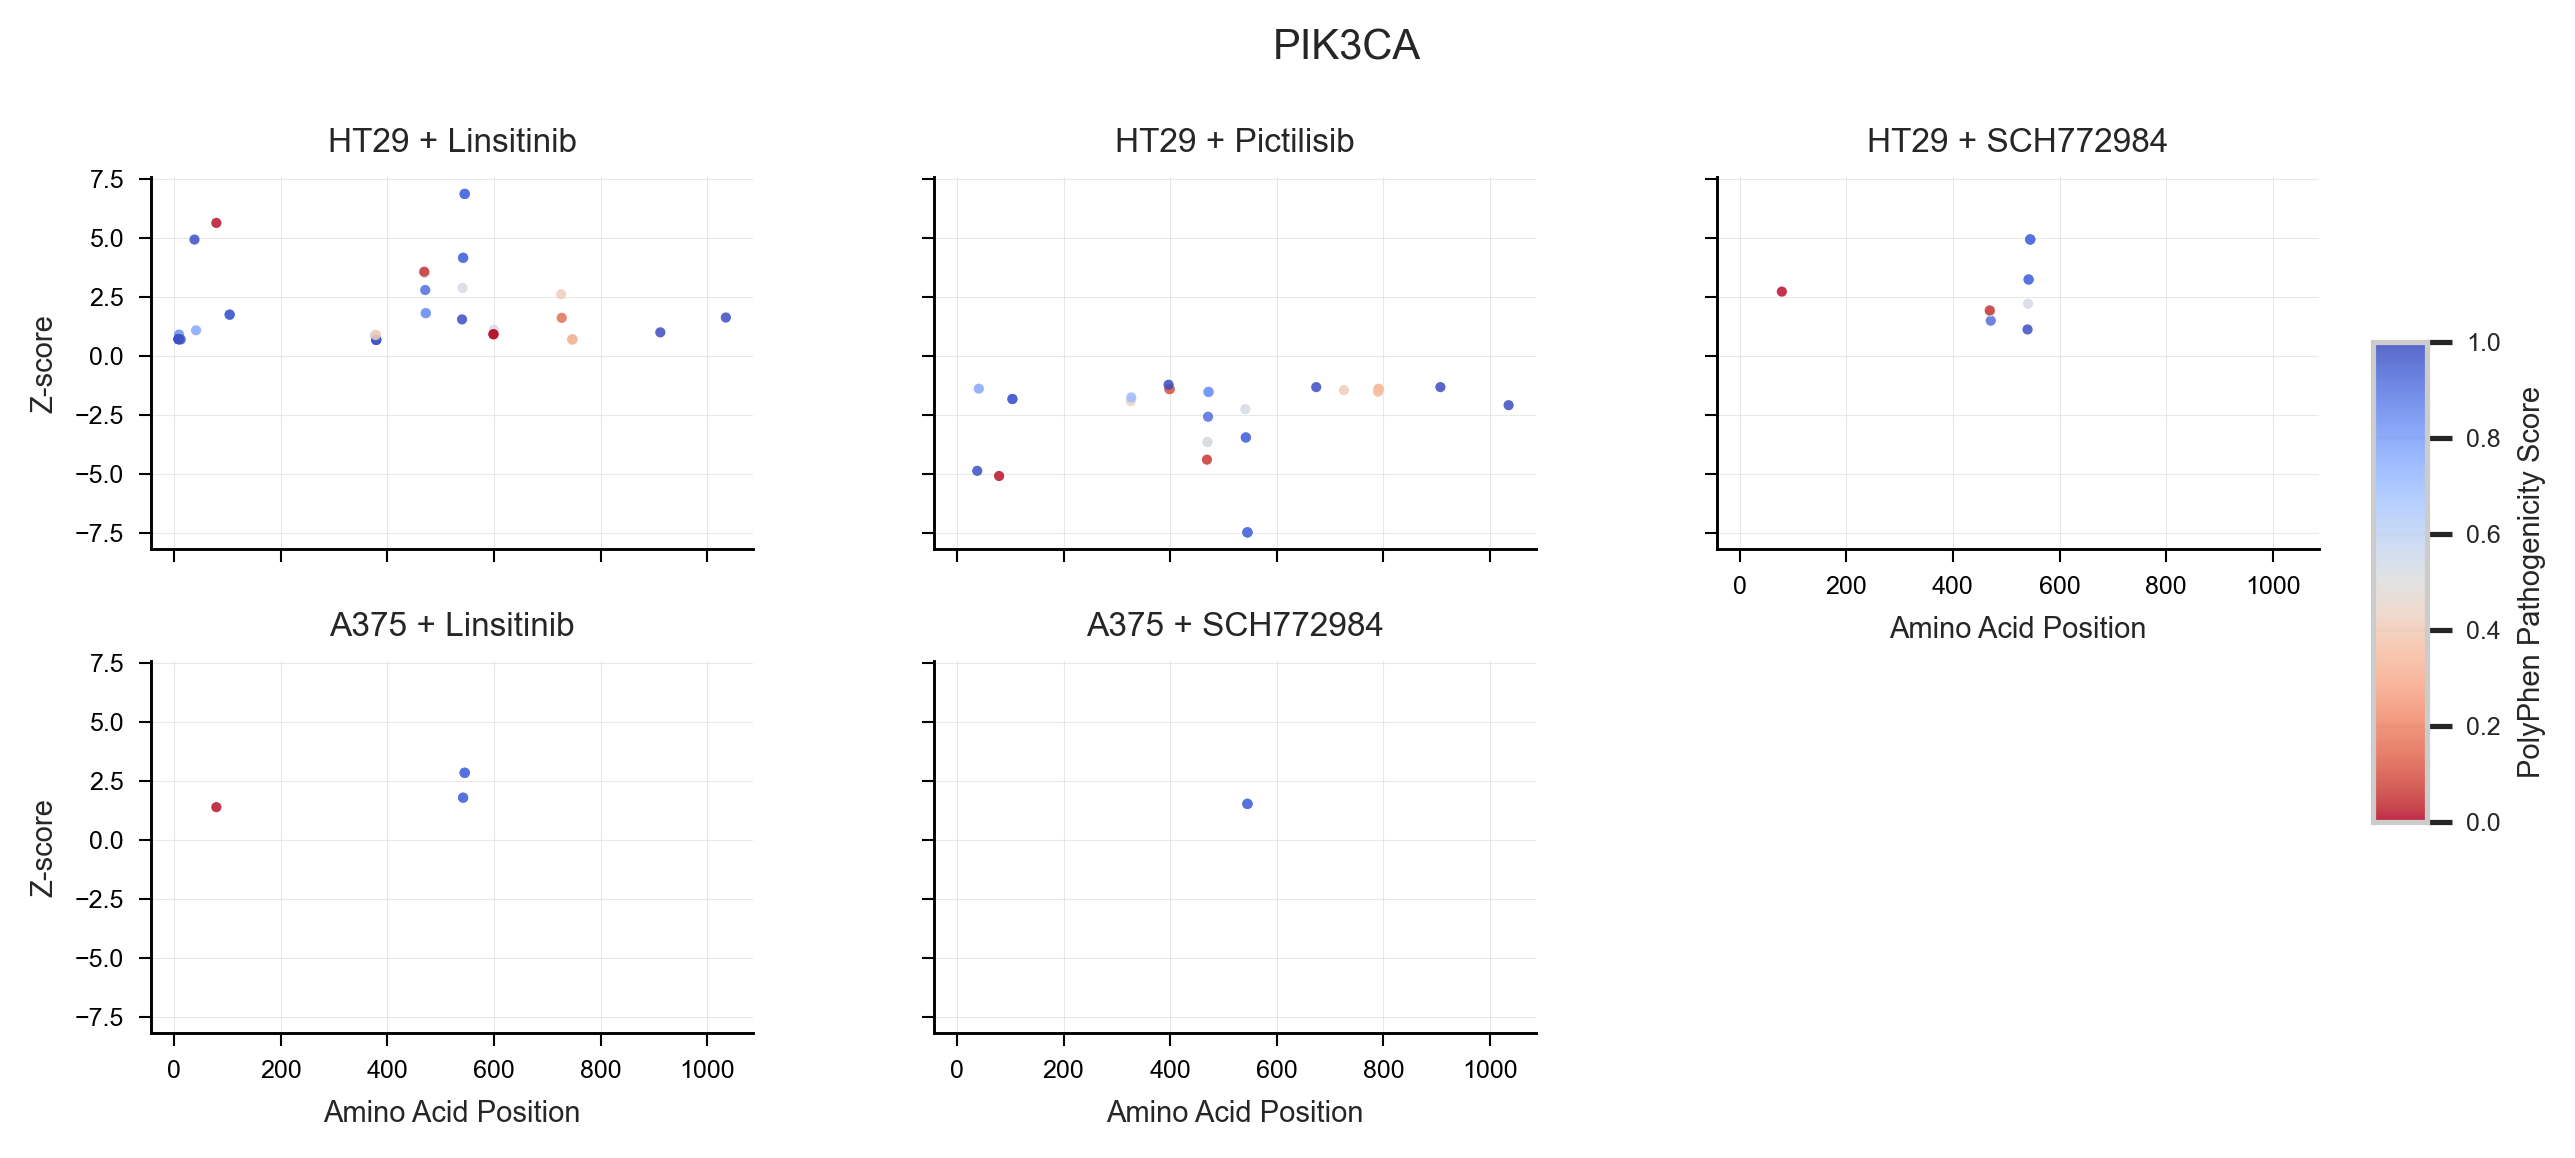

In [257]:
plot_pathogenicity_gradient(PIK3CA_merged_vep_min_pos, patho_score="PolyPhen_pathogenicity", legend="PolyPhen Pathogenicity Score")

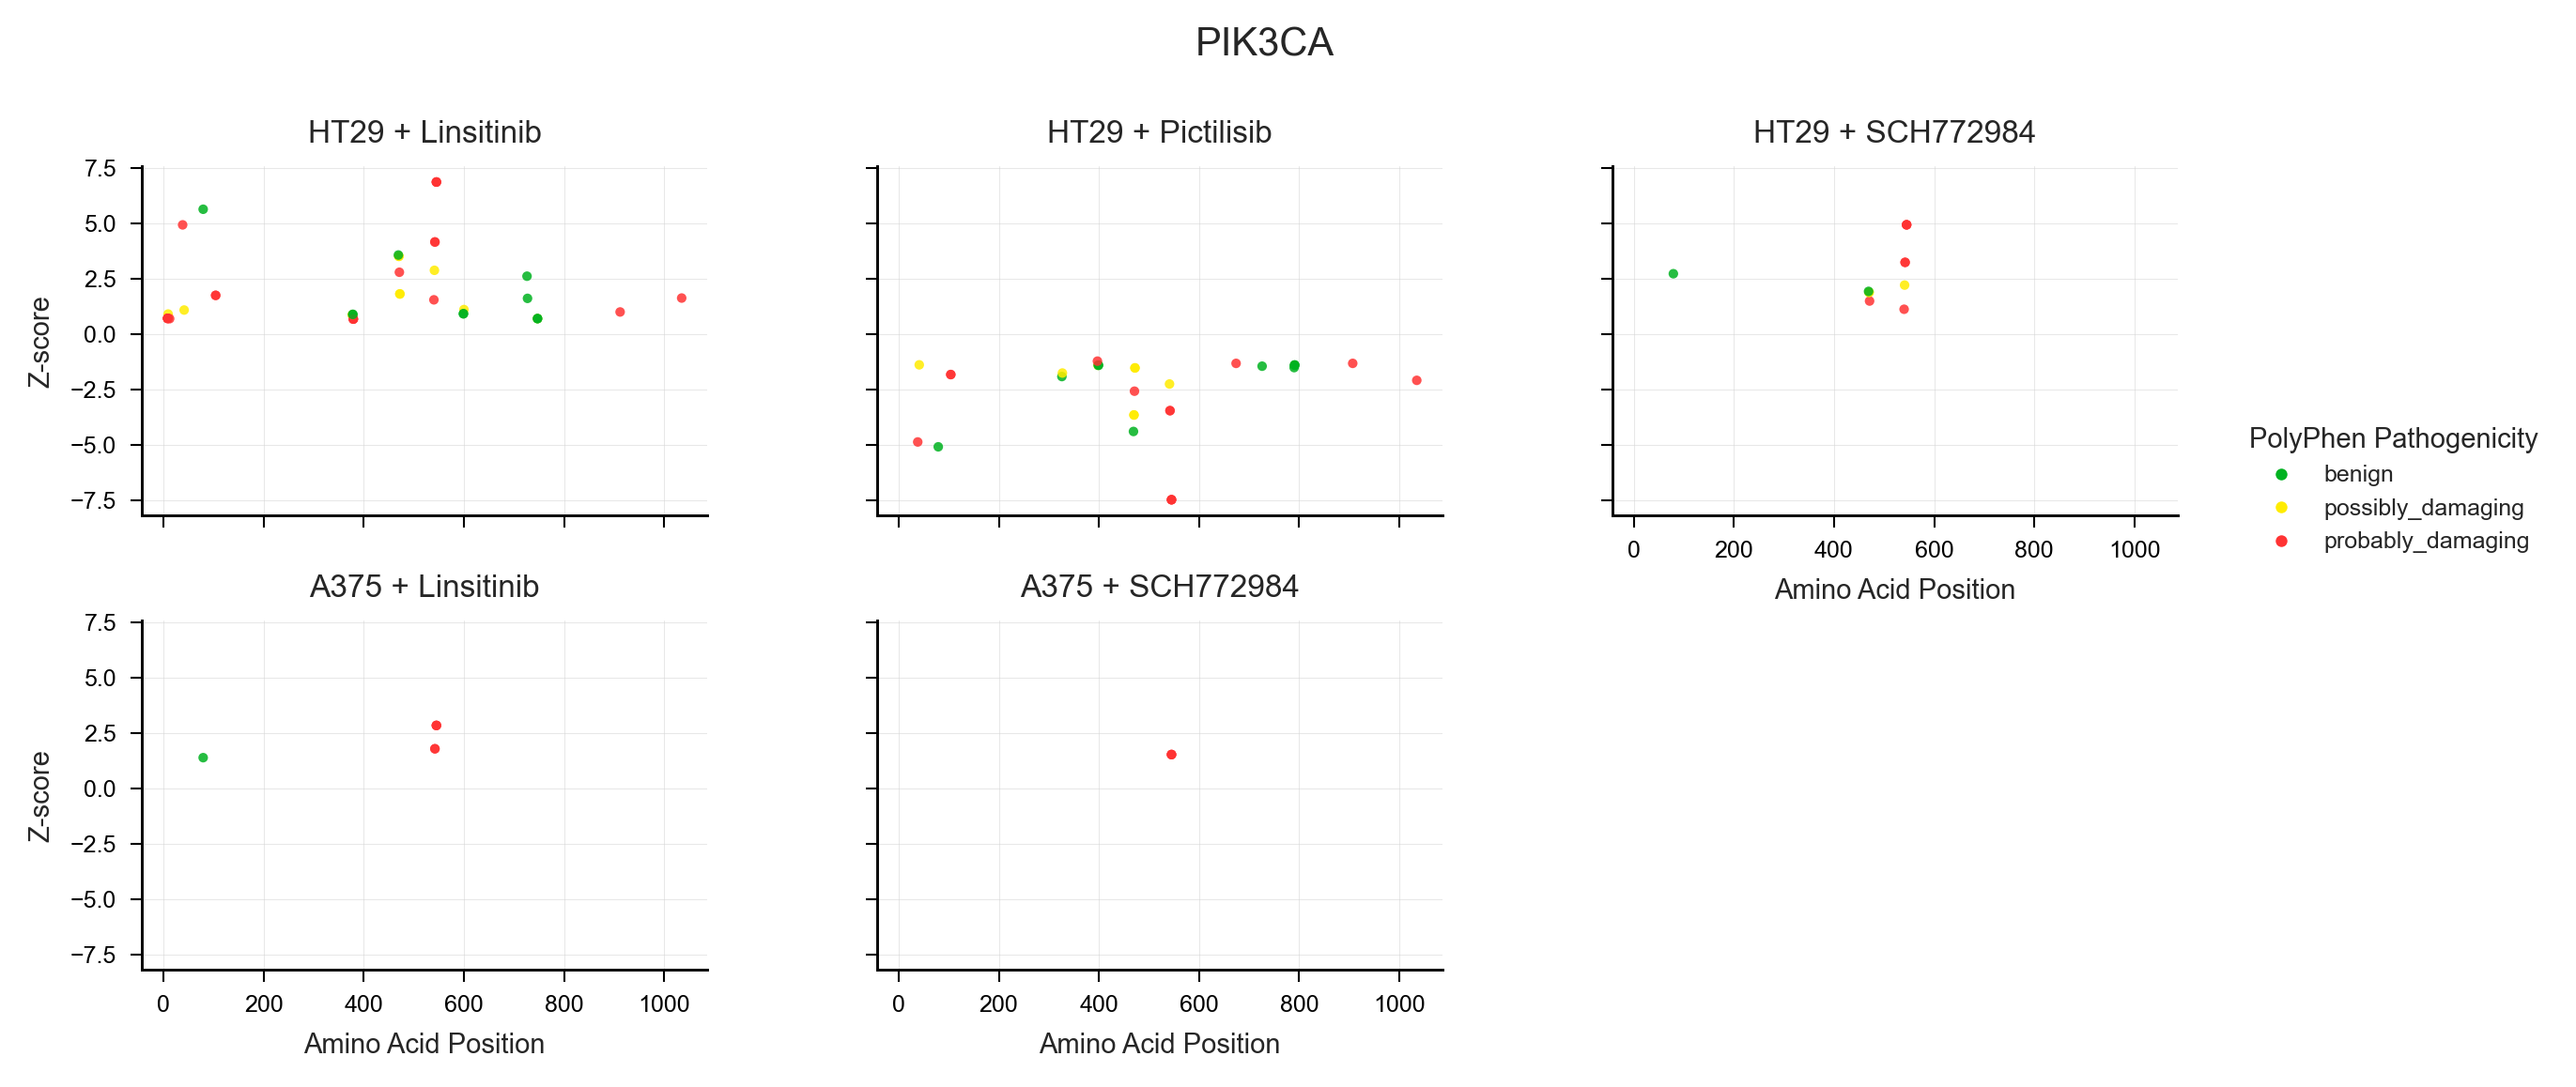

In [258]:
color_map_polyphen = {
        "benign": "#00B220",             # green
        "possibly_damaging": "#FFEC00",  # yellow
        "probably_damaging": "#FF3333",  # red
}
plot_pathogenicity_by_class(PIK3CA_merged_vep_min_pos, patho_class="PolyPhen_class", legend="PolyPhen Pathogenicity", color_map=color_map_polyphen)

#### SIFT

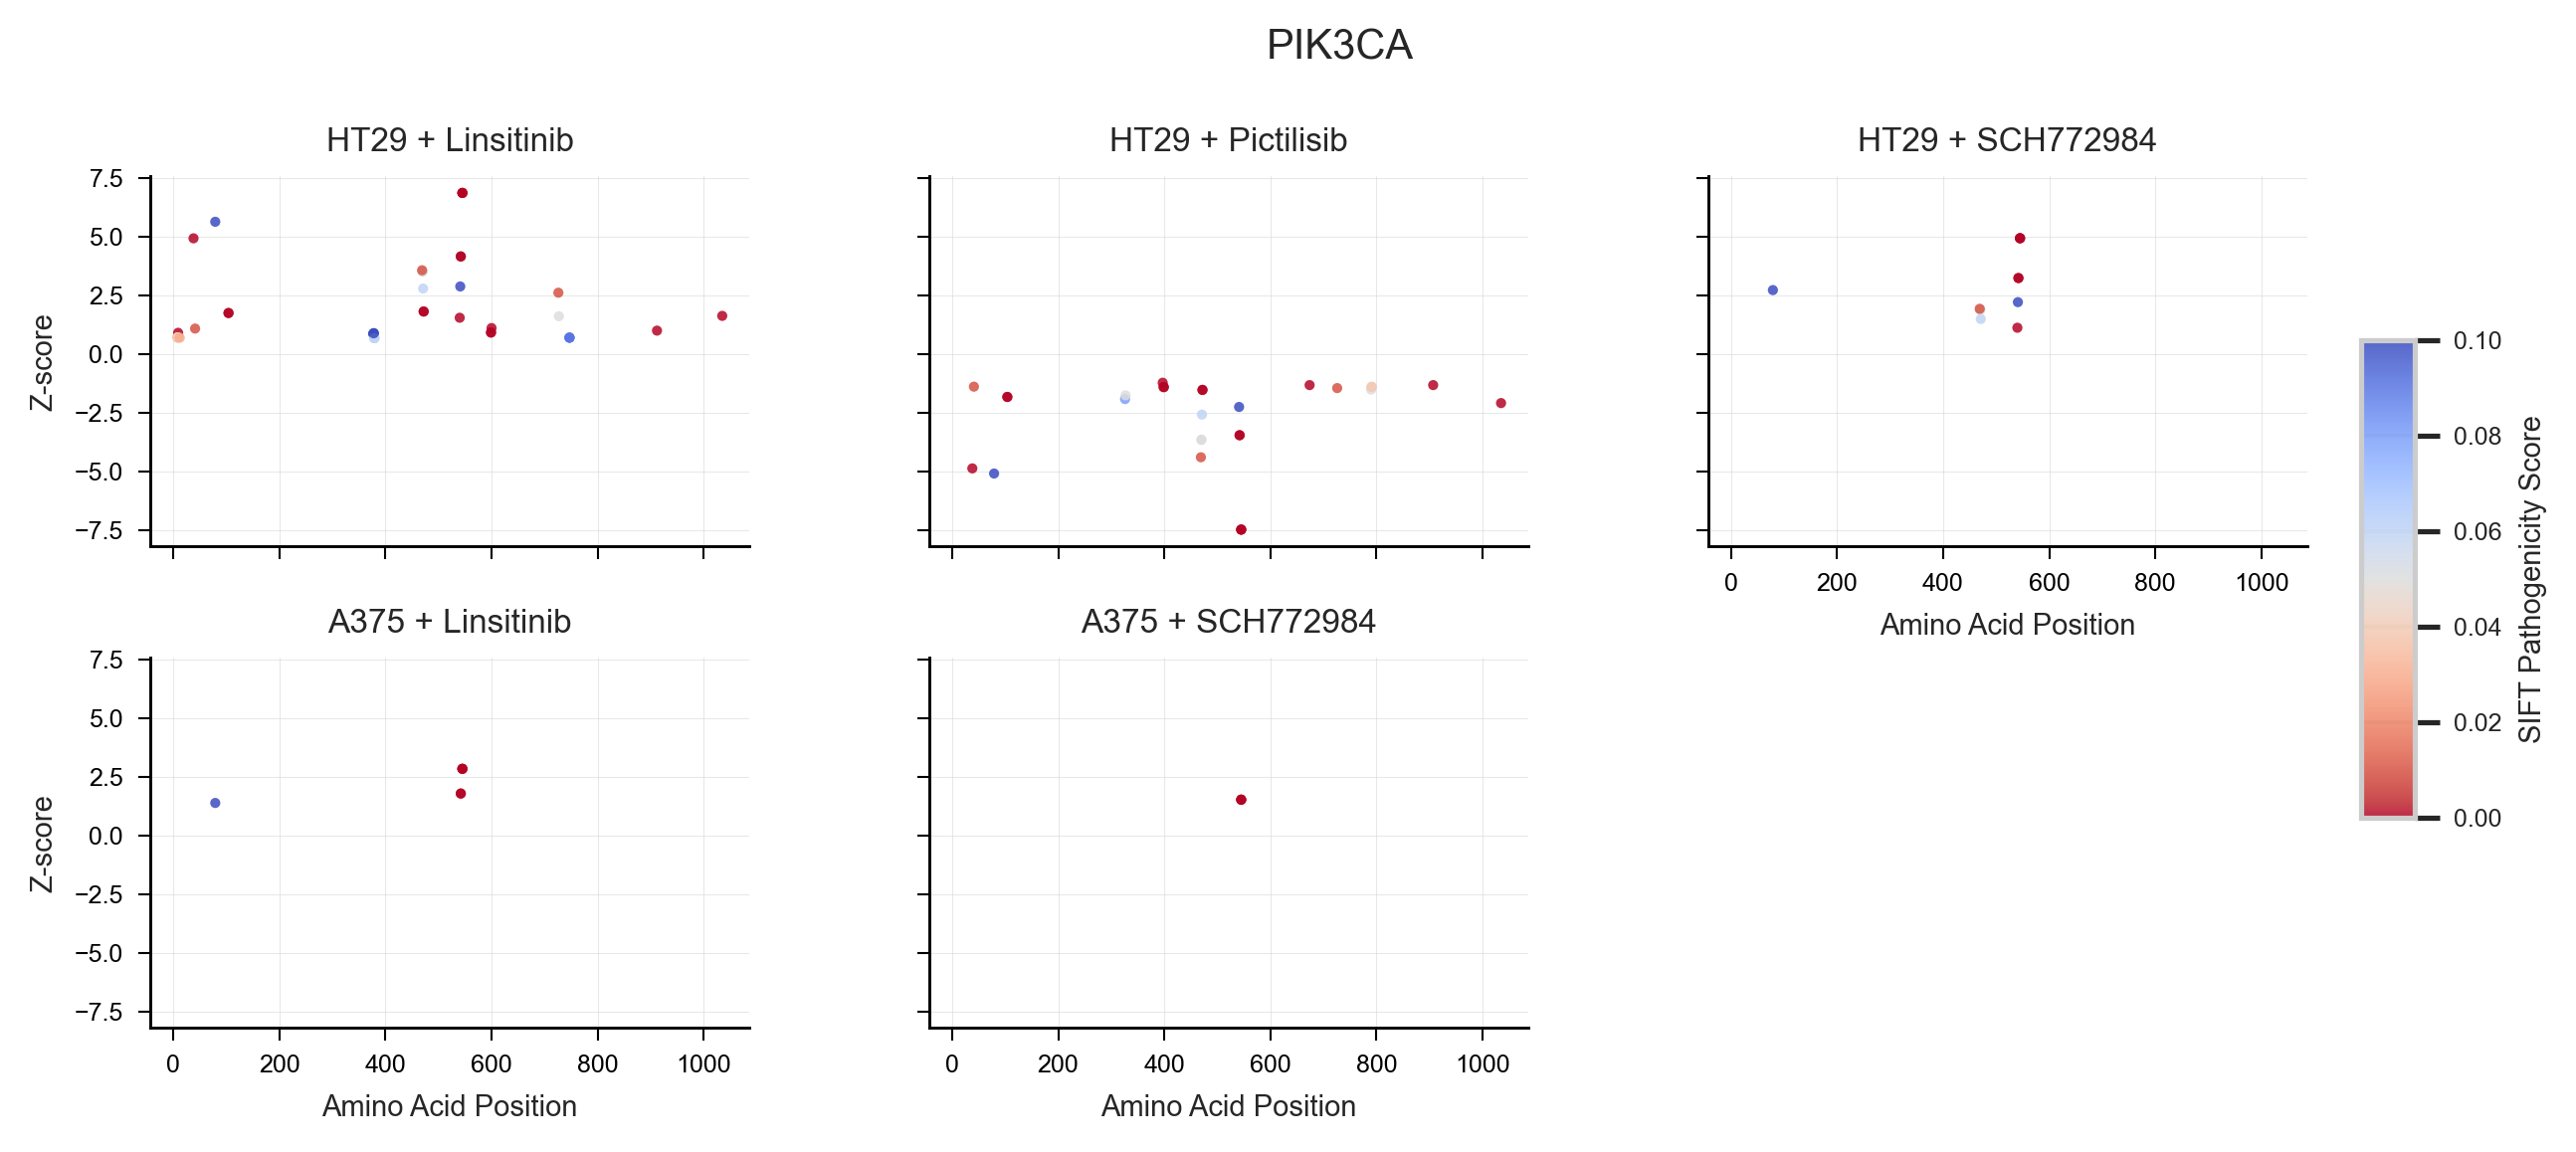

In [255]:
plot_pathogenicity_gradient(PIK3CA_merged_vep_min_pos, patho_score="SIFT_pathogenicity", legend="SIFT Pathogenicity Score")

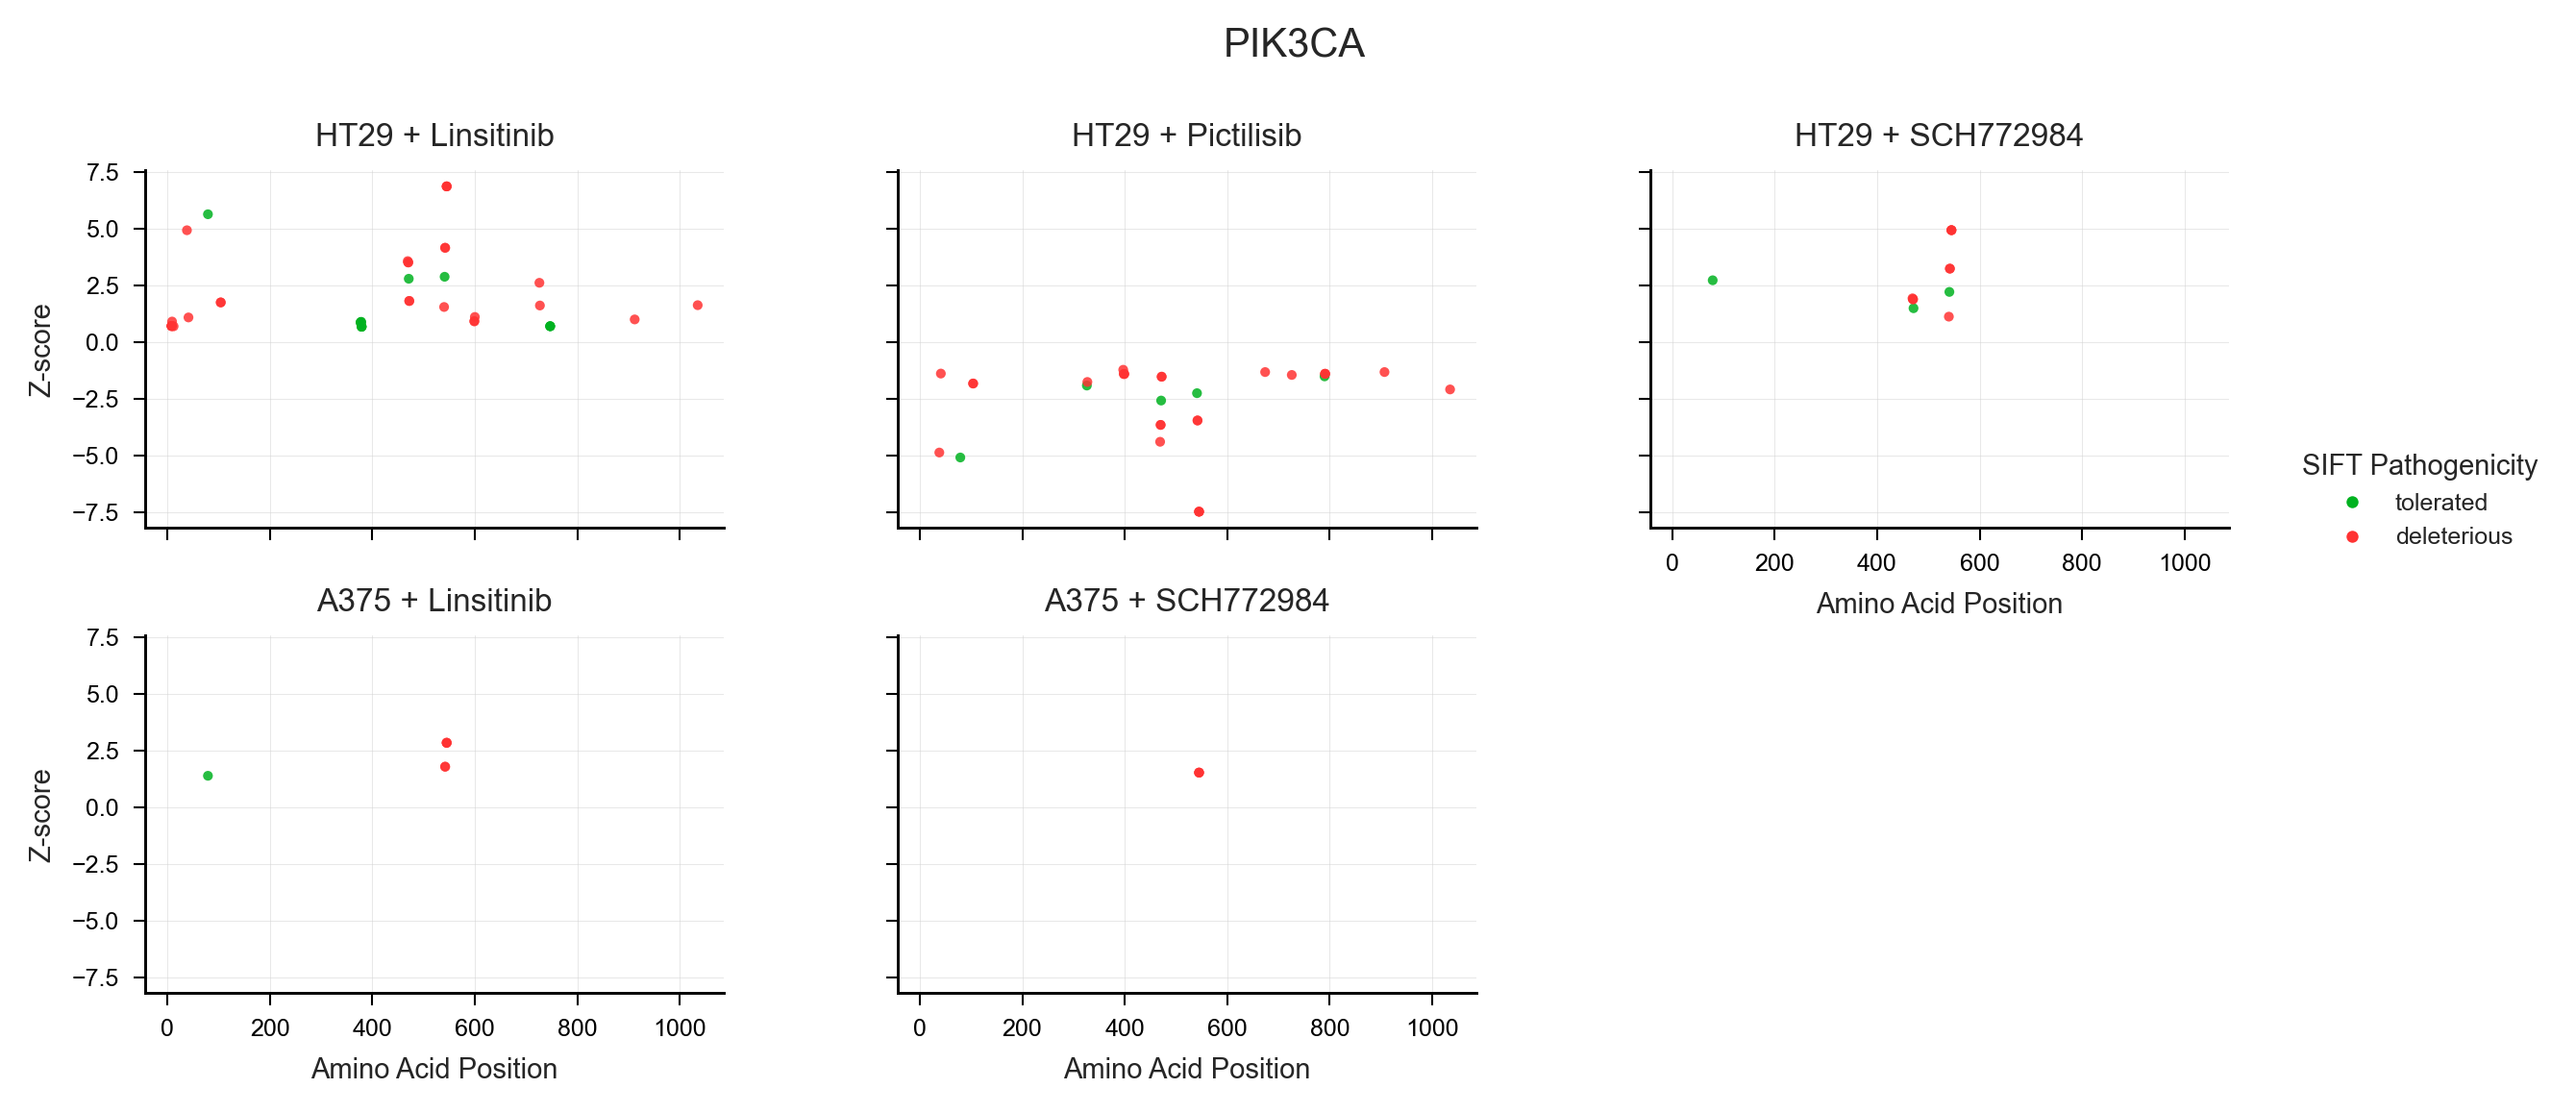

In [259]:
color_map_SIFT = {
        "tolerated": "#00B220",             # green
        "deleterious": "#FF3333",  # red
}
plot_pathogenicity_by_class(PIK3CA_merged_vep_min_pos, patho_class="SIFT_class", legend="SIFT Pathogenicity", color_map=color_map_SIFT)

In [228]:
PIK3CA_merged_vep['SIFT_class'].unique()

array([0.02, 0.04, 0.  ,  nan, 0.03, 0.01, 0.26, 0.06, 0.08, 0.05, 0.32,
       0.28, 0.1 , 0.18, 0.12, 0.09, 0.13, 0.23])

#### AlphaMissense

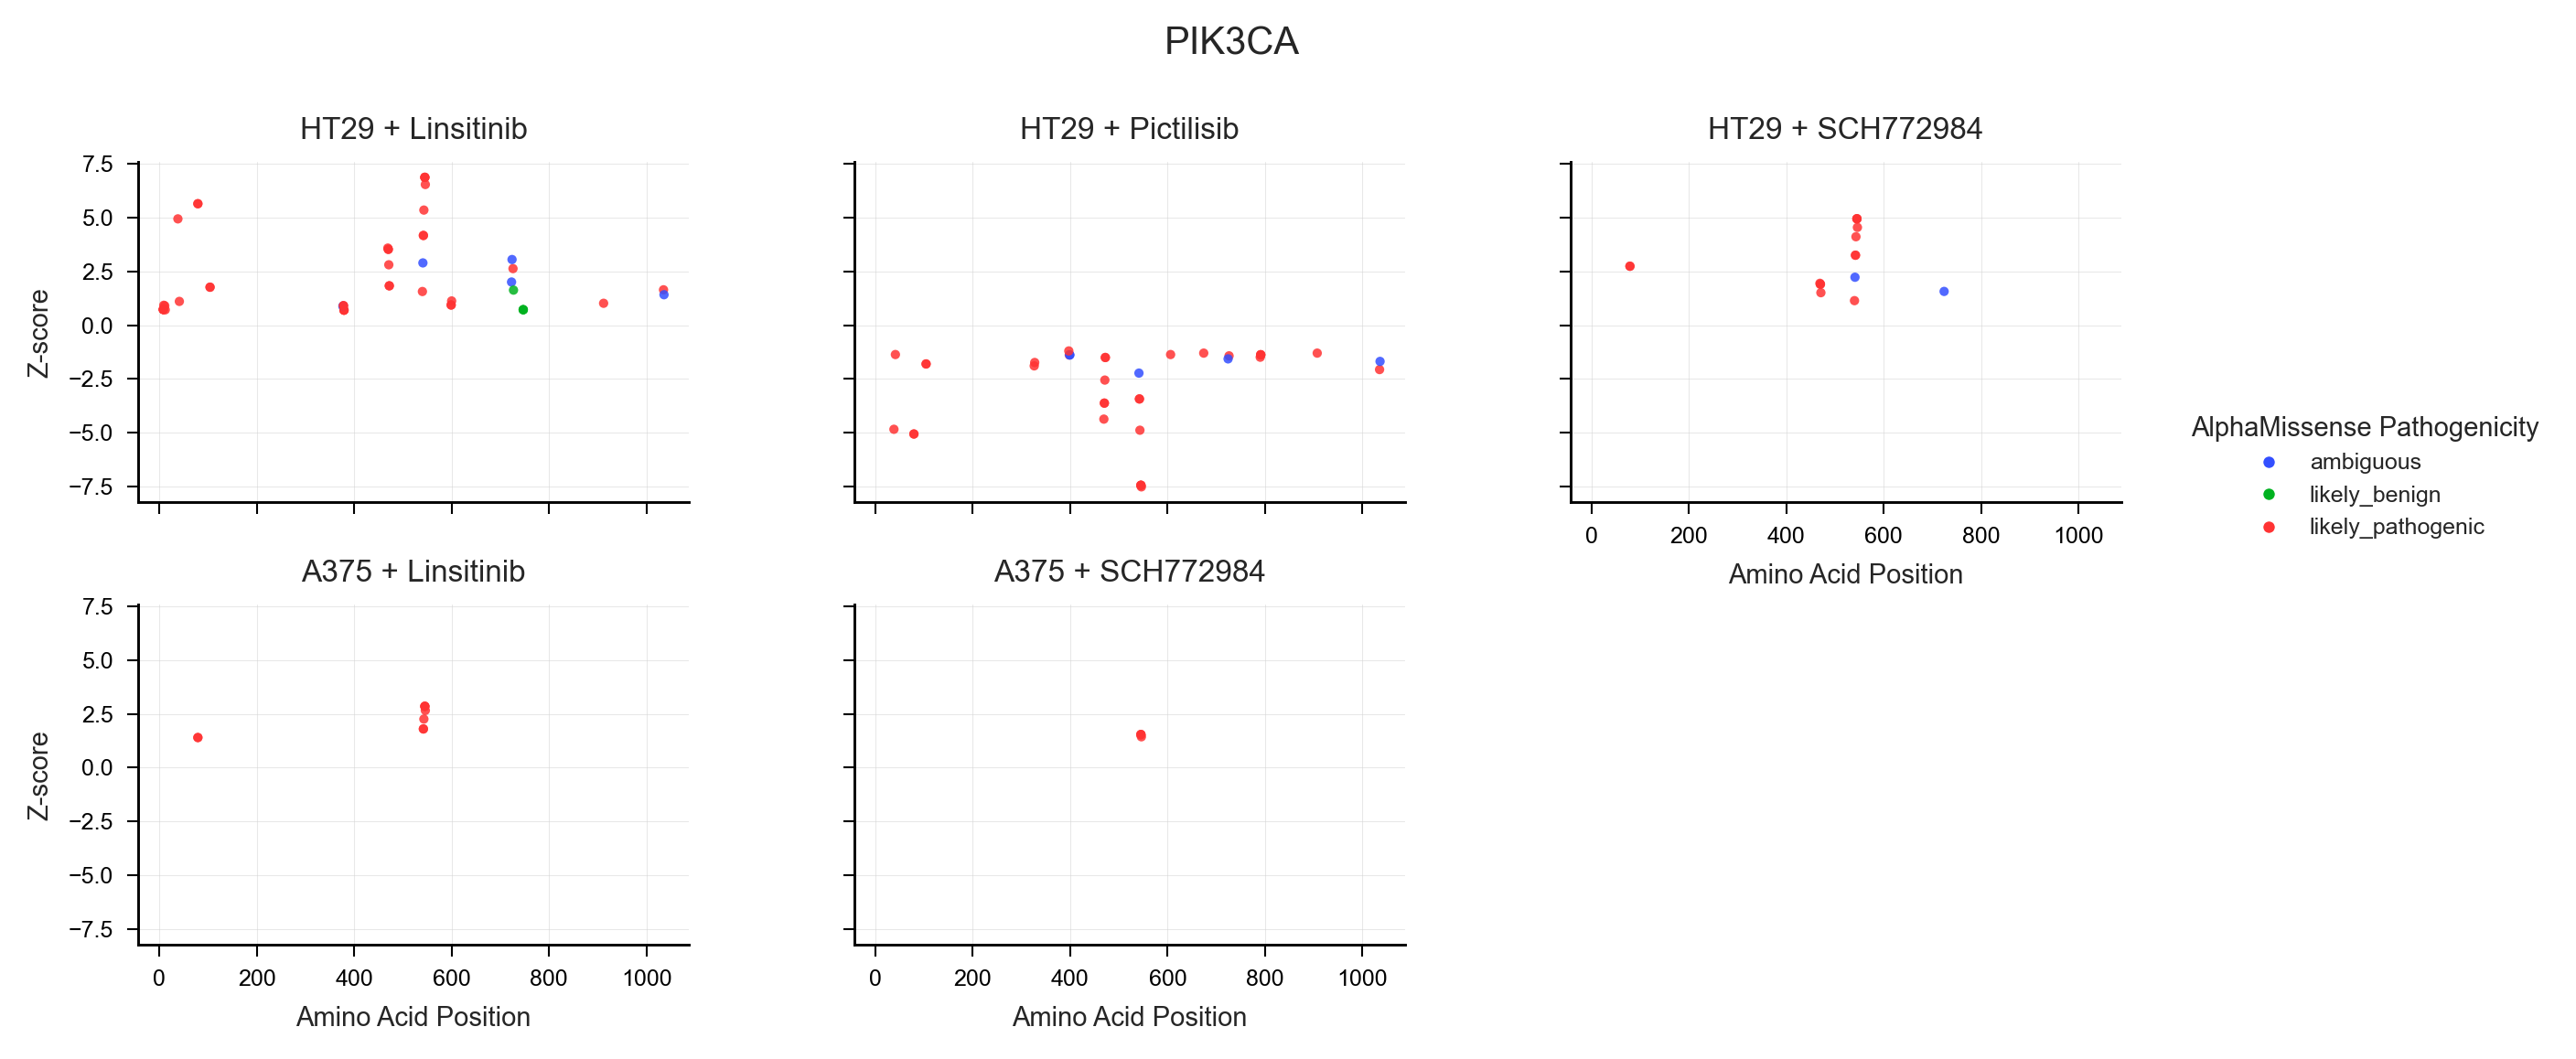

In [252]:
color_map_AM = {
        "ambiguous": "#334FFF",           # blue
        "likely_benign": "#00B220",      # green
        "likely_pathogenic": "#FF3333",  # red
}
plot_pathogenicity_by_class(PIK3CA_merged_vep_most_patho, patho_class="am_class", legend="AlphaMissense Pathogenicity", color_map=color_map_AM)

In [248]:
PIK3CA_merged_vep_min_pos['am_class'].unique()

array(['likely_pathogenic', 'ambiguous', nan, 'likely_benign'],
      dtype=object)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

gradient = np.linspace(0, 1, 256).reshape(1, -1)

fig, axs = plt.subplots(len(plt.colormaps()), 1, figsize=(8, 60))

for ax, name in zip(axs, plt.colormaps()):
    ax.imshow(gradient, aspect='auto', cmap=plt.get_cmap(name))
    ax.set_title(name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [41]:
MC_beagle = pd.read_csv("data/1_Beagle_design_files/MC/MC_guides.txt", sep="\t")

In [42]:
MC_beagle.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,ENST00000644969,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000644969.2,CDS,GCCACCATCATGGCAGCATC,AGTAGCCACCATCATGGCAGCATCTGCTCT,TG,140726475,sense,"140726491T>C, 140726488T>C","A_4, A_7","*3A>G, *6A>G","(NC), (NC)","UTR, UTR",NaN,NaN
1,ENST00000644969,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000644969.2,CDS,GCCACCATCATGGCAGCATC,AGTAGCCACCATCATGGCAGCATCTGCTCT,TG,140726475,sense,"140726490G>A, 140726489G>A","C_5, C_6","*4C>T, *5C>T","(NC), (NC)","UTR, UTR",NaN,NaN
2,ENST00000644969,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000644969.2,CDS,CTGCCATGATGGTGGCTACT,GATGCTGCCATGATGGTGGCTACTTGAAGG,TG,140726479,antisense,140726484A>G,A_6,*10T>C,(NC),UTR,NaN,NaN
3,ENST00000644969,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000644969.2,CDS,CTGCCATGATGGTGGCTACT,GATGCTGCCATGATGGTGGCTACTTGAAGG,TG,140726479,antisense,"140726483C>T, 140726482C>T","C_5, C_4","*11G>A, *12G>A","(NC), (NC)","UTR, UTR",NaN,NaN
4,ENST00000644969,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000644969.2,CDS,CAAGTAGCCACCATCATGGC,CCTTCAAGTAGCCACCATCATGGCAGCATC,AG,140726481,sense,140726495T>C,A_6,2423A>G,Ter808Trp,Missense,NaN,NaN


In [43]:
MC_beagle['Target Gene Symbol'].unique()

array(['BRAF', 'KRAS', 'BCL2', 'PIK3CA', 'MYC', 'AKT1', 'PARP2', 'EGFR',
       'PARP1', 'MAP2K1', 'MAP2K2'], dtype=object)

In [44]:
MC_beagle['Target Transcript ID'].unique() 

array(['ENST00000644969.2', 'ENST00000311936.8', 'ENST00000333681.5',
       'ENST00000263967.4', 'ENST00000621592.8', 'ENST00000649815.2',
       'ENST00000429687.8', 'ENST00000275493.7', 'ENST00000366794.10',
       'ENST00000307102.10', 'ENST00000262948.10'], dtype=object)

In [48]:
unique_comb= MC_beagle[['Target Gene Symbol', 'Target Transcript ID']].drop_duplicates(keep='first')

In [50]:
MC_transcripts= MC_beagle.drop_duplicates(subset=['Target Gene Symbol', 'Target Transcript ID'], keep='first', ignore_index=True)

In [51]:
MC_transcripts

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,ENST00000644969,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000644969.2,CDS,GCCACCATCATGGCAGCATC,AGTAGCCACCATCATGGCAGCATCTGCTCT,TG,140726475,sense,"140726491T>C, 140726488T>C","A_4, A_7","*3A>G, *6A>G","(NC), (NC)","UTR, UTR",NaN,NaN
1,ENST00000311936,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,TG,25209787,sense,"25209803T>C, 25209800T>C","A_4, A_7","559A>G, 562A>G","Ile187Val, Met188Val","Missense, Missense",NaN,NaN
2,ENST00000333681,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000018.10,ENSG00000171791,BCL2,-,ENST00000333681.5,CDS,GCAGGCATGTTGACTTCACT,TGGGGCAGGCATGTTGACTTCACTTGTGGC,TG,63128610,antisense,63128616A>G,A_7,*9T>C,(NC),UTR,NaN,NaN
3,ENST00000263967,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CATTGTTCTGATTCTTTGCA,GAGGCATTGTTCTGATTCTTTGCAAGTTTT,AG,179198809,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENST00000621592,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000008.11,ENSG00000136997,MYC,+,ENST00000621592.8,CDS,GTCTAAGCAGCTGCAAGGAG,CAGCGTCTAAGCAGCTGCAAGGAGAGCCTT,AG,127736573,antisense,"127736587T>C, 127736588T>C","A_6, A_5","-7T>C, -6T>C","(NC), (NC)","UTR, UTR",NaN,NaN
5,ENST00000649815,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000014.9,ENSG00000142208,AKT1,-,ENST00000649815.2,CDS,GGTGGACTGCGCTGGACGAT,CGGCGGTGGACTGCGCTGGACGATAGCTTG,AG,104770315,sense,104770329T>C,A_6,*12A>G,(NC),UTR,NaN,NaN
6,ENST00000429687,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,PARP2,+,ENST00000429687.8,CDS,TCAGCGTTCGAATTCCATGG,GACGTCAGCGTTCGAATTCCATGGCGGCGC,CG,20343626,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ENST00000275493,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,CTCCCCGAAGAGCTCGCTCC,GCTGCTCCCCGAAGAGCTCGCTCCGGCTCT,GG,55019253,antisense,55019265T>C,A_8,-13T>C,(NC),UTR,NaN,NaN
8,ENST00000366794,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000001.11,ENSG00000143799,PARP1,-,ENST00000366794.10,CDS,GAGGTAGCCGAGTCACACCC,GGGAGAGGTAGCCGAGTCACACCCGGTGGC,GG,226361434,sense,226361448T>C,A_6,*12A>G,(NC),UTR,NaN,NaN
9,ENST00000307102,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,ACCCGGGTCCAAAATGCCCA,CGTTACCCGGGTCCAAAATGCCCAAGAAGA,AG,66387335,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
MC_transcripts = MC_transcripts.copy()
MC_transcripts["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in MC_transcripts.iterrows()
]

In [54]:
#Flatten the list of HGVS notations
variants_MC_hgvs = [v for vs in MC_transcripts["hgvs"] if vs != "-" for v in vs]

In [55]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/MC_transcripts", "w") as f:
    for variant in variants_MC_hgvs:
        f.write(f"{variant}\n")

In [57]:
EG_transcripts= EG_beagle.drop_duplicates(subset=['Target Gene Symbol', 'Target Transcript ID'], keep='first', ignore_index=True)

In [59]:
EG_transcripts = EG_transcripts.copy()
EG_transcripts["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in EG_transcripts.iterrows()
]

In [60]:
#Flatten the list of HGVS notations
variants_EG_hgvs = [v for vs in EG_transcripts["hgvs"] if vs != "-" for v in vs]

In [61]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/EG_transcripts", "w") as f:
    for variant in variants_EG_hgvs:
        f.write(f"{variant}\n")

In [63]:
#Load VEP results
#'-' is a placeholder for missing values in the VEP file 
EG_transcripts_VEP = pd.read_csv("/Users/carolinapinto/desktop/Tese/Data/VEP_EG_transcripts.txt", sep="\t", na_values="-")

In [64]:
len(EG_transcripts_VEP)

474

In [65]:
#drop duplicated rows
EG_transcripts_VEP = EG_transcripts_VEP.drop_duplicates(ignore_index=True)

In [96]:
len(EG_transcripts_VEP)

474

In [97]:
EG_transcripts.columns

Index(['Input', 'CRISPR Enzyme', 'Edit Type', 'Edit Window', 'Target Taxon',
       'Target Assembly', 'Target Genome Sequence', 'Target Gene ID',
       'Target Gene Symbol', 'Target Gene Strand', 'Target Transcript ID',
       'Target Domain', 'sgRNA Sequence', 'sgRNA Context Sequence',
       'PAM Sequence', 'sgRNA Sequence Start Pos. (global)',
       'sgRNA Orientation', 'Nucleotide Edits (global)', 'Guide Edits',
       'Nucleotide Edits', 'Amino Acid Edits', 'Mutation Category',
       'Constraint Violations', 'Note', 'hgvs'],
      dtype='object')

In [101]:
EG_beagle[EG_beagle['Target Gene Symbol'] == 'HRAS'].head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
4962,ENST00000311189.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000011.10,ENSG00000174775,HRAS,-,ENST00000311189.8,CDS,CTCTCCTGACGCAGGTGAGG,TGTGCTCTCCTGACGCAGGTGAGGGGGACT,GG,532625,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4963,ENST00000311189.8,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000011.10,ENSG00000174775,HRAS,-,ENST00000311189.8,CDS,CTCTCCTGACGCAGGTGAGG,TGTGCTCTCCTGACGCAGGTGAGGGGGACT,GG,532625,sense,532640G>A;532639G>A,C_5;C_6,566C>T;567C>T,Ser189Phe,Missense,NaN,NaN
4964,ENST00000311189.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000011.10,ENSG00000174775,HRAS,-,ENST00000311189.8,CDS,GCTCTCCTGACGCAGGTGAG,GTGTGCTCTCCTGACGCAGGTGAGGGGGAC,GG,532626,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4965,ENST00000311189.8,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000011.10,ENSG00000174775,HRAS,-,ENST00000311189.8,CDS,GCTCTCCTGACGCAGGTGAG,GTGTGCTCTCCTGACGCAGGTGAGGGGGAC,GG,532626,sense,"532642G>A, 532640G>A;532639G>A","C_4, C_6;C_7","564C>T, 566C>T;567C>T","Leu188Leu, Ser189Phe","Silent, Missense",NaN,NaN
4966,ENST00000311189.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000011.10,ENSG00000174775,HRAS,-,ENST00000311189.8,CDS,TGCTCTCCTGACGCAGGTGA,TGTGTGCTCTCCTGACGCAGGTGAGGGGGA,GG,532627,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
EG_transcripts

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs
0,ENST00000275493.7,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,CGCATCGCTGCTCCCCGAAG,GGGTCGCATCGCTGCTCCCCGAAGAGCTCG,AG,55019263,antisense,55019279T>C,A_4,2T>C,Met1Thr,Missense,NaN,NaN,[ENST00000275493.7:c.2T>C]
1,ENST00000311936.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,TG,25209787,sense,"25209803T>C, 25209800T>C","A_4, A_7","559A>G, 562A>G","Ile187Val, Met188Val","Missense, Missense",NaN,NaN,"[ENST00000311936.8:c.559A>G, ENST00000311936.8..."
2,ENST00000369535.5,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,NRAS,-,ENST00000369535.5,CDS,ATGTAACAAGGTGAGCATAT,GGTGATGTAACAAGGTGAGCATATGGTTTC,GG,114708521,sense,"114708536T>C;114708535T>C, 114708533T>C","A_5;A_6, A_8","569A>G;570A>G, *2A>G","Ter190Trp, (NC)","Missense, UTR",NaN,NaN,"[ENST00000369535.5:c.569A>G, ENST00000369535.5..."
3,ENST00000311189.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000011.10,ENSG00000174775,HRAS,-,ENST00000311189.8,CDS,CTCTCCTGACGCAGGTGAGG,TGTGCTCTCCTGACGCAGGTGAGGGGGACT,GG,532625,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-
4,ENST00000646891.2,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,ENST00000646891.2,CDS,CTGAAACAAATGAGTGAGAG,TCCACTGAAACAAATGAGTGAGAGAGTTCA,AG,140734581,sense,"140734597T>C, 140734596T>C, 140734595T>C, 1407...","A_4, A_5, A_6, A_8","2301A>G, *1A>G, *2A>G, *4A>G","Ter767Trp, (NC), (NC), (NC)","Missense, UTR, UTR, UTR",NaN,NaN,"[ENST00000646891.2:c.2301A>G, ENST00000646891...."
5,ENST00000251849.9,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000003.12,ENSG00000132155,RAF1,-,ENST00000251849.9,CDS,CTTCTAGTTGACTTTGCACC,CTGTCTTCTAGTTGACTTTGCACCTGTCTT,TG,12584501,sense,12584515T>C,A_6,1946A>G,Ter649Trp,Missense,NaN,NaN,[ENST00000251849.9:c.1946A>G]
6,ENST00000267101.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000065361,ERBB3,+,ENST00000267101.8,CDS,ATGACTCCGCAGAGGGTGAA,CCTCATGACTCCGCAGAGGGTGAAGGGAGC,GG,56080283,antisense,56080299T>C,A_4,-2T>C,(NC),UTR,NaN,NaN,[ENST00000267101.8:c.-2T>C]
7,ENST00000269571.10,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000017.11,ENSG00000141736,ERBB2,+,ENST00000269571.10,CDS,ATGGTGCTCACTGCGGCTCC,CTCCATGGTGCTCACTGCGGCTCCGGCCCC,GG,39700221,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-
8,ENST00000215832.11,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000022.11,ENSG00000100030,MAPK1,-,ENST00000215832.11,CDS,TAAATTTGTCAGGTACCTGG,ATCTTAAATTTGTCAGGTACCTGGAGTTTA,AG,21769187,sense,21769203T>C,A_4,*1A>G,(NC),UTR,NaN,NaN,[ENST00000215832.11:c.*1A>G]
9,ENST00000263025.9,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000016.10,ENSG00000102882,MAPK3,-,ENST00000263025.9,CDS,CTAGCCCAGACAGACATCTC,CCCCCTAGCCCAGACAGACATCTCTGCACC,TG,30116652,sense,30116664T>C,A_8,*4A>G,(NC),UTR,NaN,NaN,[ENST00000263025.9:c.*4A>G]


In [110]:
EG_check=EG_transcripts_VEP[EG_transcripts_VEP['#Uploaded_variation']=='ENST00000275493.7:c.2T>C']

In [111]:
EG_check[['SYMBOL', 'Feature', 'CANONICAL', 'MANE', 'MANE_SELECT']]

,SYMBOL,Feature,CANONICAL,MANE,MANE_SELECT
408,EGFR,ENST00000275493.7,YES,MANE_Select,NM_005228.5
409,EGFR,ENST00000342916.7,NaN,NaN,NaN
410,EGFR,ENST00000344576.7,NaN,NaN,NaN
411,EGFR,ENST00000420316.6,NaN,NaN,NaN
412,EGFR,ENST00000455089.5,NaN,NaN,NaN
413,EGFR,ENST00000459688.2,NaN,NaN,NaN
414,EGFR,ENST00000463948.1,NaN,NaN,NaN
415,EGFR,ENST00000700144.1,NaN,NaN,NaN
416,NaN,ENST00000836965.1,YES,NaN,NaN
417,NaN,ENSR7_D4PP2,NaN,NaN,NaN


In [106]:
unique_comb_1= EG_transcripts_VEP[['#Uploaded_variation', 'SYMBOL', 'MANE']].drop_duplicates(keep='first')